In [60]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, cophenet
from scipy.spatial.distance import pdist
from sklearn.decomposition import PCA

### Load the Dataset

In [61]:
country_data_df = pd.read_csv("../data/Country-data.csv")
country_data_df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


### Check the Overview of the DataFrame

In [62]:
def basic_checks(data):
    print("-"*35, "Duplicates","-"*35)
    print(data.duplicated().sum())
    print("-"*35, "Shape", "-"*35)
    print(data.shape)
    print("-"*35, "Missing Values", "-"*35)
    print(data.isna().sum())
    print("-"*35, "Data Types", "-"*35)
    print(data.dtypes)
    print("-"*35, "Summary Statistics (Numerical)", "-"*35)
    print(display(data.describe().T))
    print("-"*35, "Summary Statistics Categorical Data", "-"*35)
    print(display(data.describe(include = ["str","object"]).T))


In [63]:
basic_checks(country_data_df)

----------------------------------- Duplicates -----------------------------------
0
----------------------------------- Shape -----------------------------------
(167, 10)
----------------------------------- Missing Values -----------------------------------
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64
----------------------------------- Data Types -----------------------------------
country           str
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object
----------------------------------- Summary Statistics (Numerical) -----------------------------------


,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


None
----------------------------------- Summary Statistics Categorical Data -----------------------------------


,count,unique,top,freq
country,167,167,Afghanistan,1


None


### Step 1: EDA

In [64]:
# Dropping the country column
features= country_data_df.drop(columns=["country"])
features

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...
162,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [65]:
# Extracting features
feature_names = features.columns.to_list()
print(feature_names)

['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


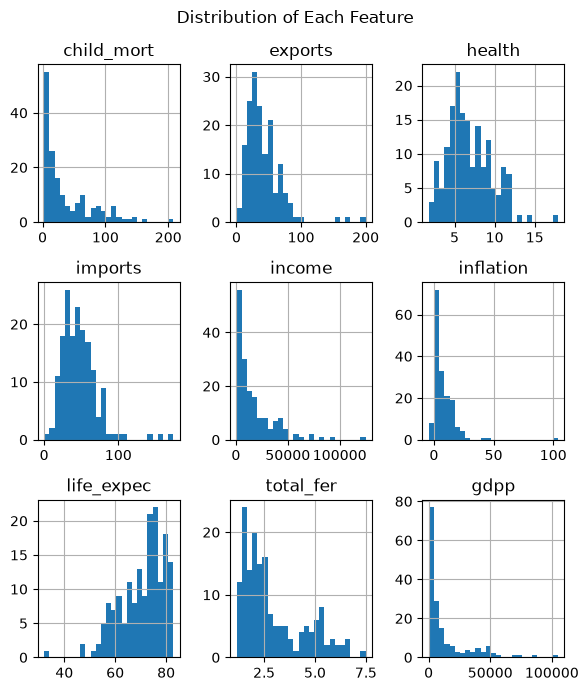

In [66]:
# Plotting the Histogram
country_data_df.hist(bins=25, figsize=(6,7))

plt.suptitle("Distribution of Each Feature")
plt.tight_layout()

plt.show()

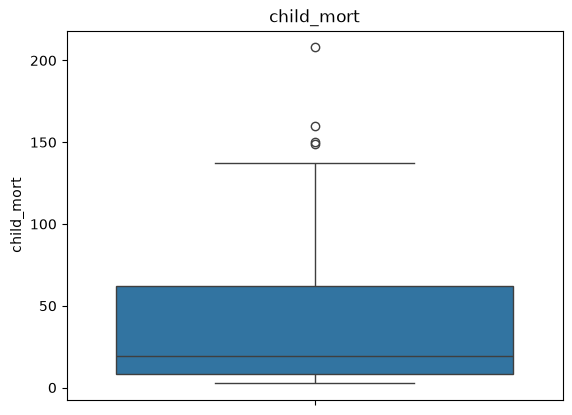

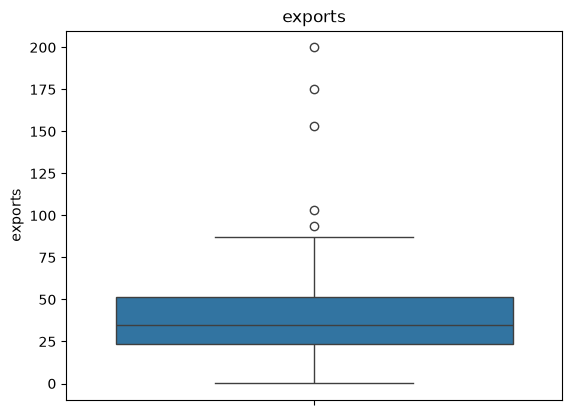

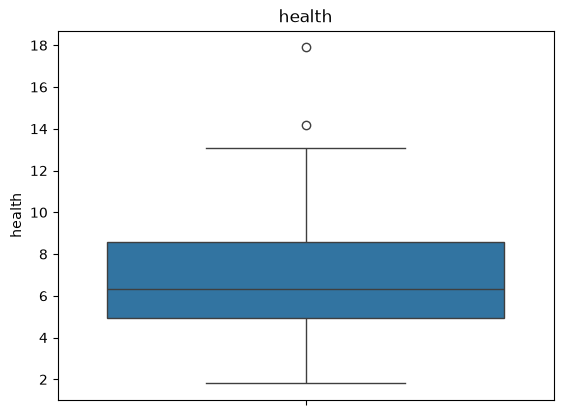

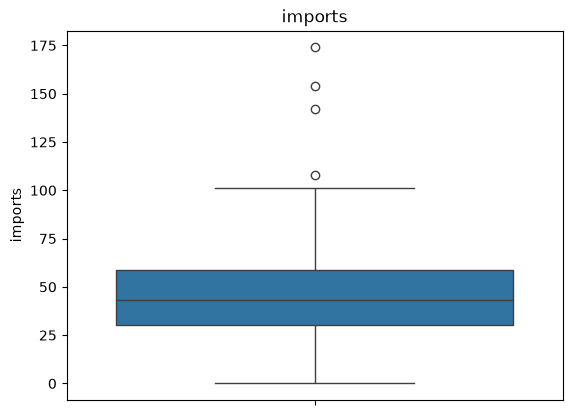

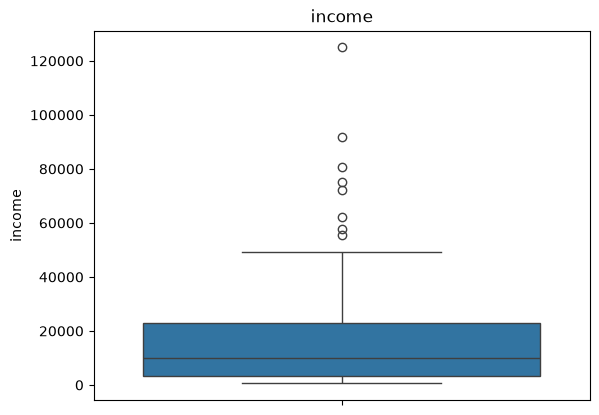

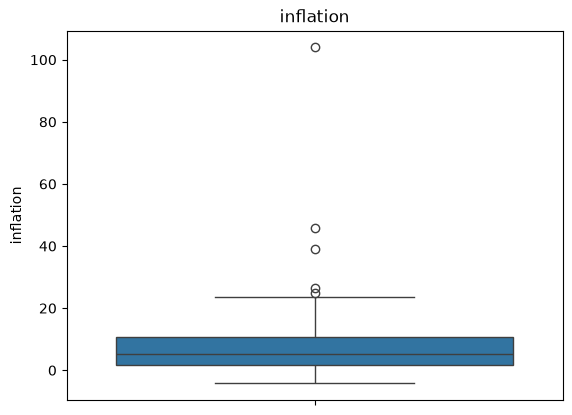

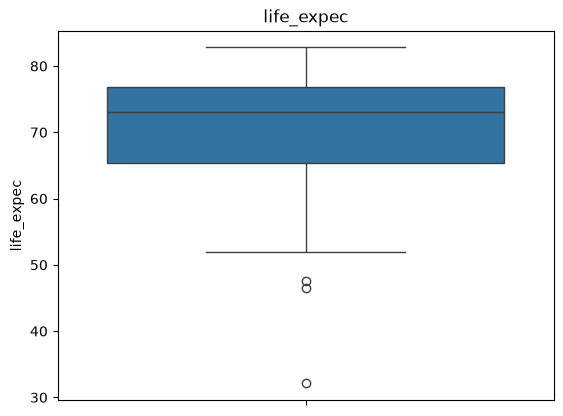

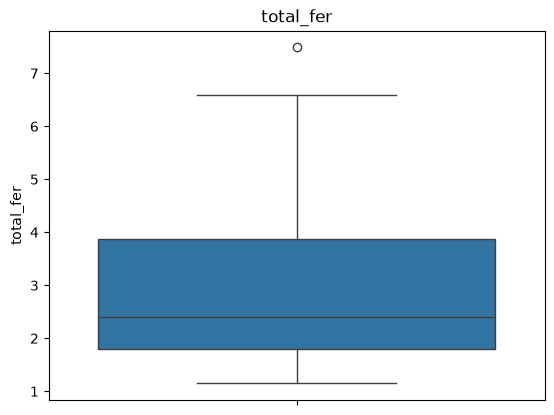

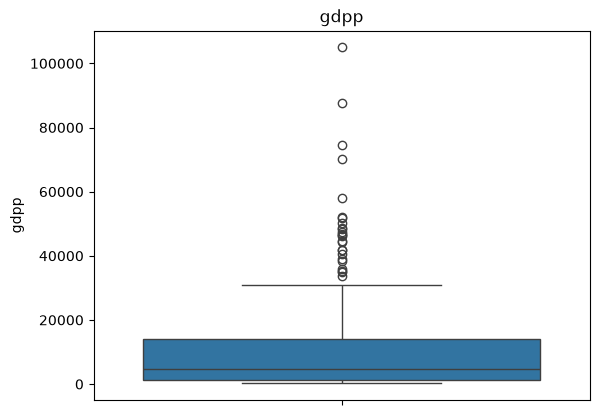

In [67]:
# Checking for Outliers
for col in feature_names:
    plt.Figure(figsize=(6,7))

    sns.boxplot(country_data_df, y=col)
    plt.title(col)
    plt.show()


In [68]:
# Corelation Analysis

correlation = country_data_df.corr(method='spearman')
correlation

ValueError: could not convert string to float: 'Afghanistan'

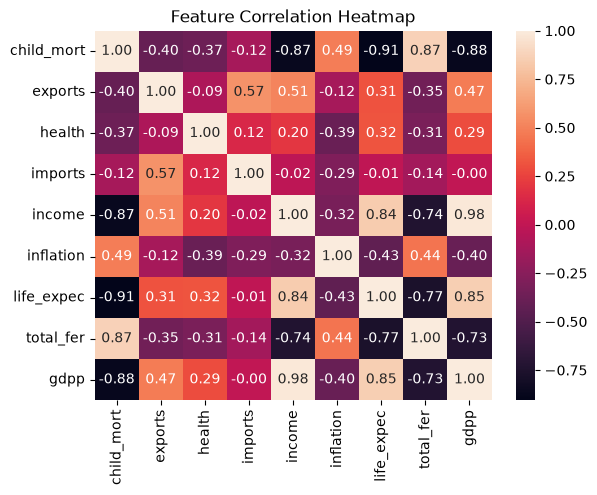

In [ ]:
# Visualizing correlation
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Feature Correlation Heatmap")

plt.show()

### Step 2: Preprocessing

In [ ]:
# Instantiate the scaler
scaler = StandardScaler()

# Scale the features
country_data_scaled = scaler.fit_transform(country_data_df)

In [ ]:
x = pd.DataFrame(country_data_scaled, columns=feature_names, index=(country_data_df.index))
x.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


### Step 3: Model 1: K-Means Clustering
#### Choosing K
##### Method a). Elbow method

In [ ]:
k_range = range(1,11)
inertias = []

for k in k_range:
    # Instantiate the K means
    km = KMeans(n_clusters=k, random_state=42,n_init=10)
    km.fit(x)
    inertias.append(km.inertia_)

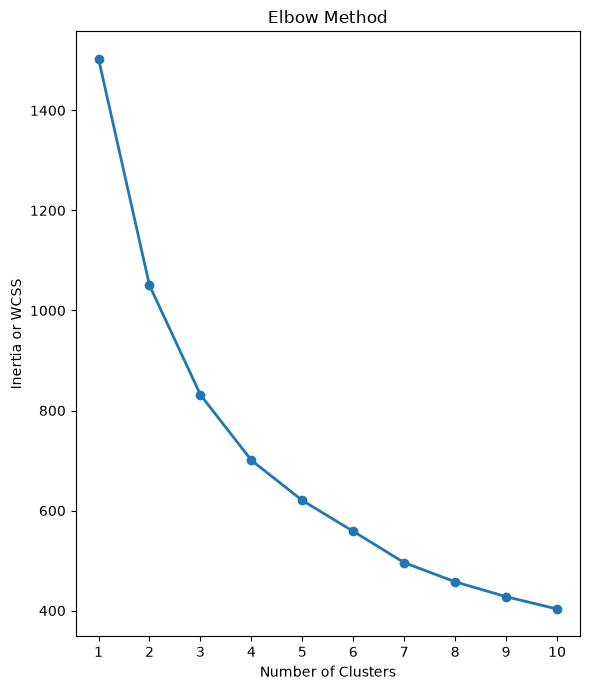

In [ ]:
# Visualizing
plt.figure(figsize=(6,7))
plt.plot(list(k_range), inertias, marker= "o", linewidth = 2)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia or WCSS")
plt.title("Elbow Method")
plt.tight_layout()
plt.xticks(list(k_range))

plt.show()



##### Method b). Silhouette Score



In [ ]:
sil_range = range(2,11)
sil_score = []

for k in sil_range:
    km = KMeans(n_clusters= k, random_state= 42, n_init= 10)
    labels = km.fit_predict(x)
    sil_score.append(silhouette_score(x, labels))

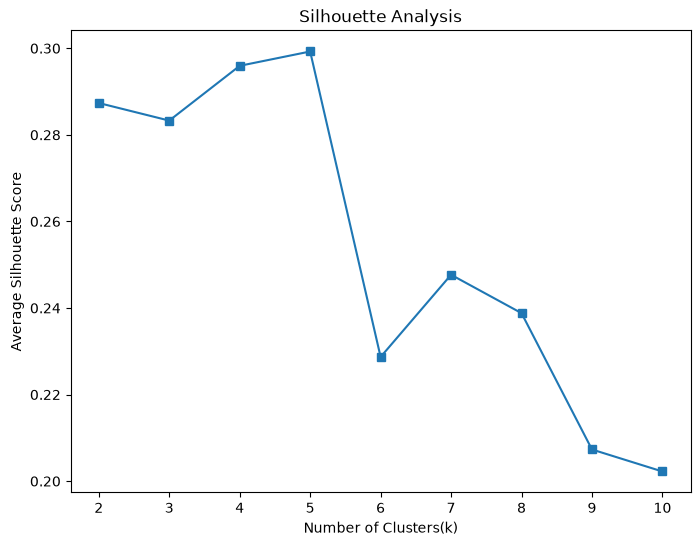

In [ ]:
plt.figure(figsize = (8,6))
plt.plot(list(sil_range), sil_score, marker = "s")
plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters(k)")
plt.ylabel("Average Silhouette Score")
plt.xticks(list(sil_range))

plt.show()

### Fitting the Final KMeans Model

In [ ]:
kmeans = KMeans(n_clusters=4, random_state= 42, n_init= 10)
kmeans_labels = kmeans.fit_predict(x)

In [ ]:
# Attach cluster number to the original dataframe
country_data_df["kmeans_cluster"] = kmeans_labels
country_data_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,kmeans_cluster
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,2
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2


### Step 4: Model 2: Hierarchical Clustering

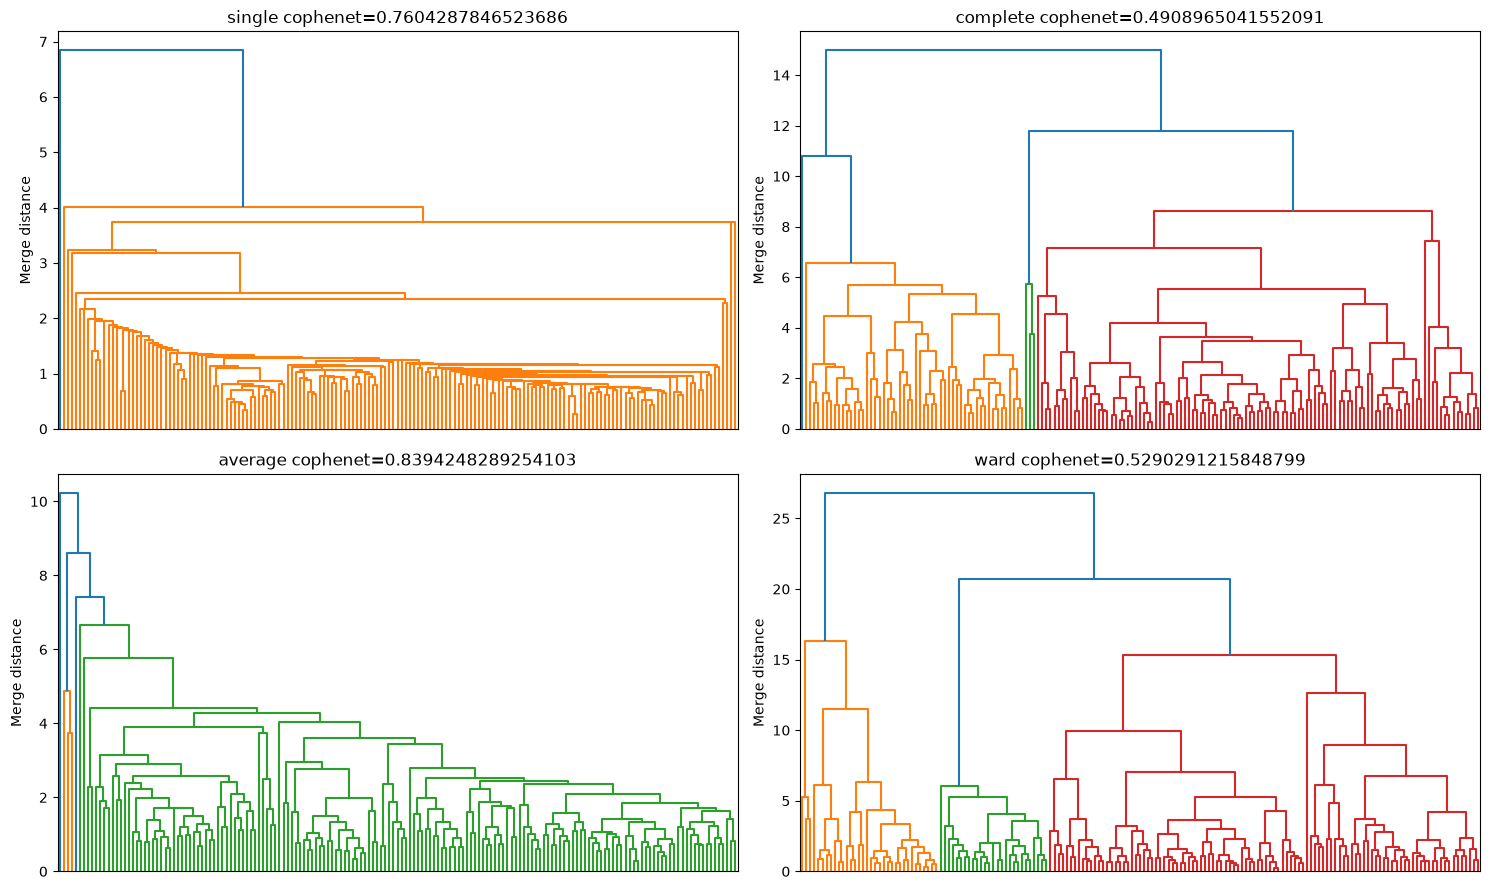

In [ ]:
# Compare Four Methods Linkage for the same data

methods = ["single", "complete", "average", "ward"]

fig, axes = plt.subplots(2,2,figsize=(15, 9))

for ax, method in zip(axes.flatten(), methods):
    Z_m = linkage(x, method = method)
    dendrogram(Z_m, ax = ax, no_labels=True)
    C, _ = cophenet(Z_m, pdist(x))
    ax.set_title(f"{method} cophenet={C}")
    ax.set_ylabel("Merge distance")

plt.tight_layout()
plt.show()

#### Building a Dendrogram Using the Average Linkage

In [69]:
country_data_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


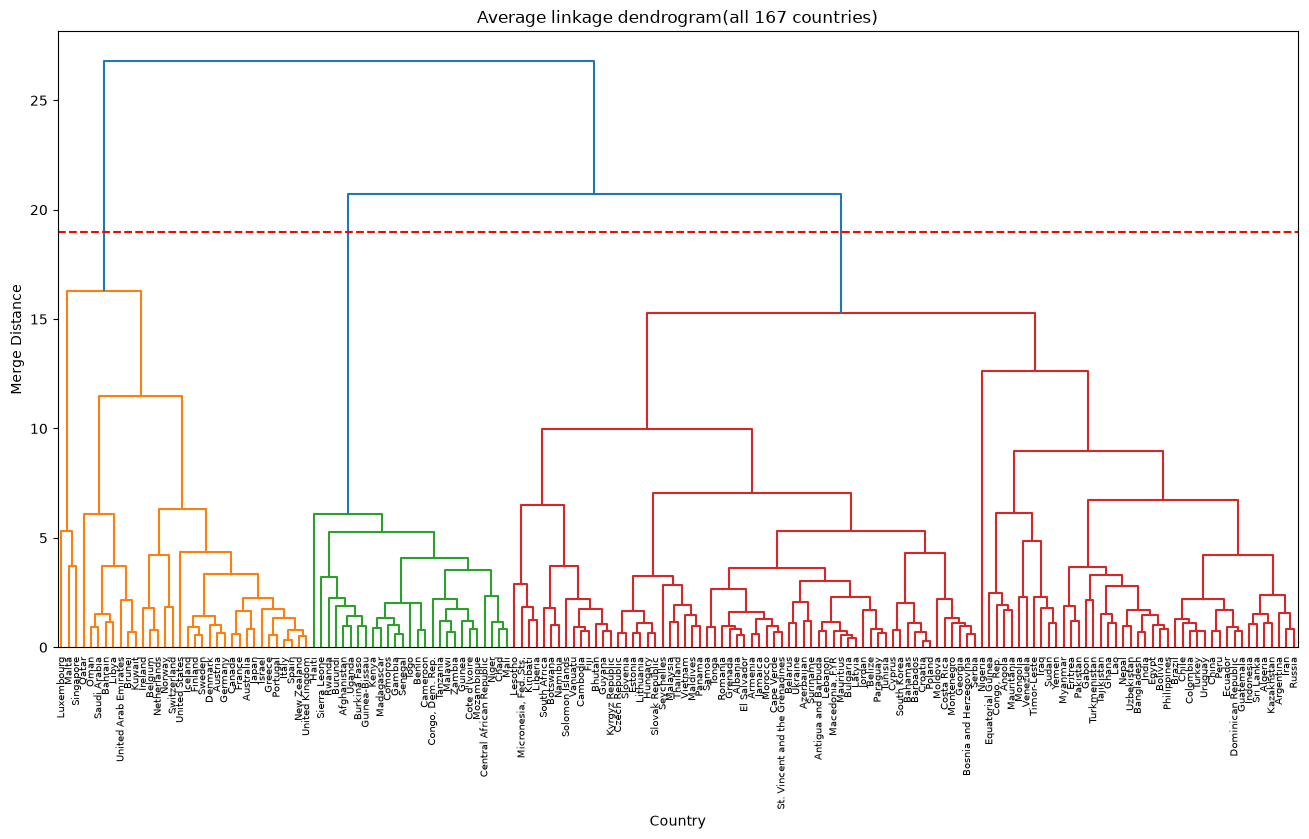

In [70]:
Z = linkage(x, method = "ward")

plt.figure(figsize=(16, 8))
dendrogram(Z, labels=country_data_df["country"].values, leaf_rotation=90, leaf_font_size=7)
plt.axhline(y=19, color="red", ls="--", label="cut here where clusters=3")
plt.title("Average linkage dendrogram(all 167 countries)")
plt.xlabel("Country")
plt.ylabel("Merge Distance")
plt.show()

### Model 2 PCA

Text(0.5, 1.0, 'Cumulative Variance Explained By Each Component')

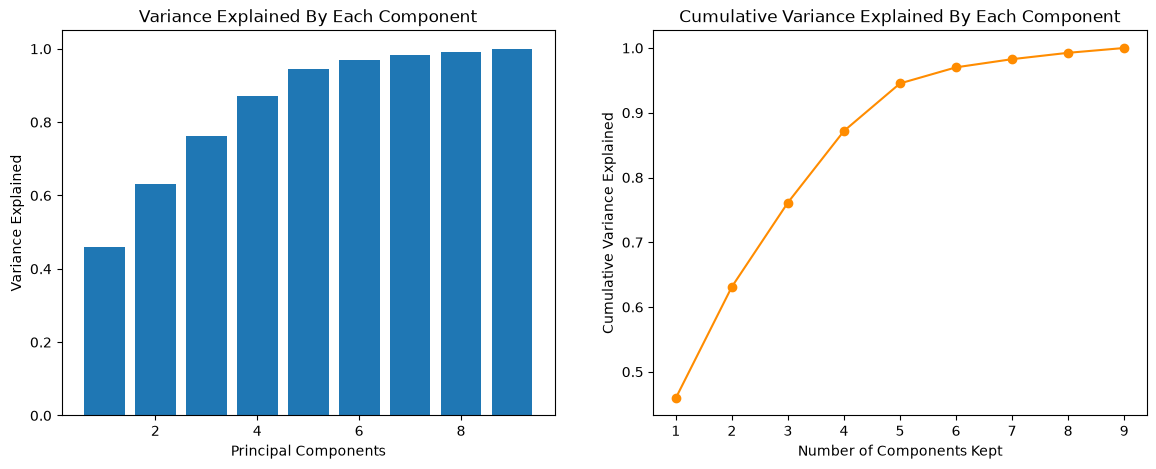

In [ ]:
pca_full = PCA(random_state=42)
pca_full.fit(x)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1,2, figsize = (14, 5))
axes[0].bar(range(1,len(explained)+ 1), cumulative)
axes[0].set_xlabel("Principal Components")
axes[0].set_ylabel("Variance Explained")
axes[0].set_title("Variance Explained By Each Component")

axes[1].plot(range(1,len(explained)+ 1), cumulative, marker = "o", color = "darkorange")
axes[1].set_xlabel("Number of Components Kept")
axes[1].set_ylabel("Cumulative Variance Explained")
axes[1].set_title("Cumulative Variance Explained By Each Component")


Text(0.5, 1.0, 'Cumulative Variance Explained By Each Component')

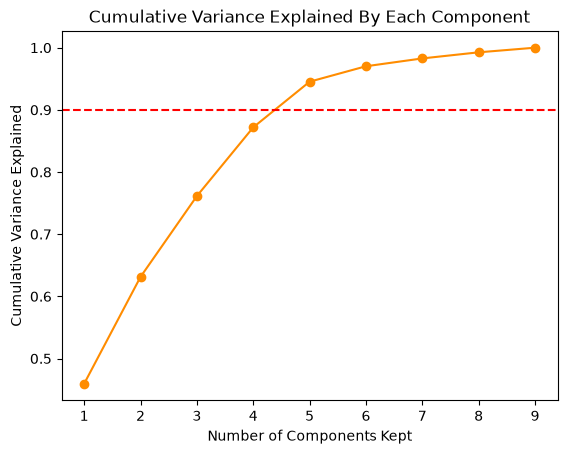

In [ ]:
plt.plot(range(1,len(explained)+ 1), cumulative, marker = "o", color = "darkorange")
plt.axhline(y= 0.90, color = "red", ls= "--", label = "90% threshold")
plt.xlabel("Number of Components Kept")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance Explained By Each Component")

In [71]:
pca_2D = PCA(n_components=2, random_state=42)
coords = pca_2D.fit_transform(x)
viz = pd.DataFrame(coords, columns=["pc1", "pc2"])

viz

,pc1,pc2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659
...,...,...
162,-0.820631,0.639570
163,-0.551036,-1.233886
164,0.498524,1.390744
165,-1.887451,-0.109453
